In [1]:
import sys
sys.path.append('/app')
# unit_test/test_single_receptor.py
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import os
from itertools import cycle

from src import (generate_receptor_indices,
                generate_cascading_receptors,
                generate_targeted_receptors,
                plot_family_summary,                
                plot_latent_radar_chart,
                evaluate_model,
                plot_summary,
                plot_latent_umap)
from run import initialize,train,test

In [9]:
n_units=3
k_sub = 5
n_families = 4
N_train = 2**16
N_test = 2**14
CONF = {
        "n_units": n_units,
        "n_families": n_families,
        "latent_dim": 3,
        "k_sub": k_sub,
        "batch_size": N_train,
        "epochs": 5000,
        "lr": 0.05,
        "cov_weight":1.,
        "n_bins":2,
        "bin_temp":0.05,
        "receptor_indices":torch.tensor([[i for _ in range(k_sub)] for i in range(n_units)],dtype=torch.long), # size must be smaller or equal to n_units
        "init_means":[np.random.randint(1,8) for _ in range(n_families)], # size must be n_families
        "shape_sigma": 0.5,
        "tolerant":False, # set whether we want tolerance for heteromers on the covariance loss
        "optimizer":"Adam",
        "momentum":0.9,
        "exact_loss":True,
        "temperature":0.1
    }

Fitting UMAP... (This may take a few seconds)


(<Figure size 500x400 with 1 Axes>,
 <Axes: title={'center': 'UMAP Projection of 3D Chemical Latent Space'}, xlabel='UMAP Dimension 1', ylabel='UMAP Dimension 2'>)

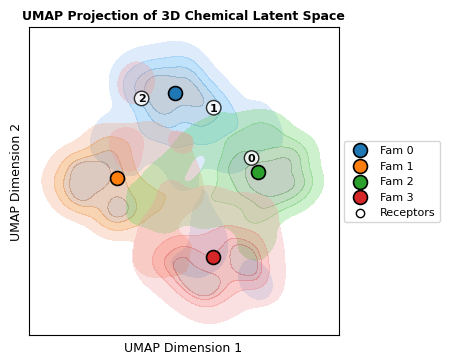

In [10]:
env,rec,loss_fn,optimize = initialize(CONF,SymmetricEnv=True)
plot_latent_umap(env,CONF["receptor_indices"])

In [11]:
stat = train(CONF,env,rec,loss_fn,optimize)
ent_test = test(CONF,env,rec,loss_fn,optimize,N_samples=N_test,indices = CONF['receptor_indices'])

Training for 5000 epochs...


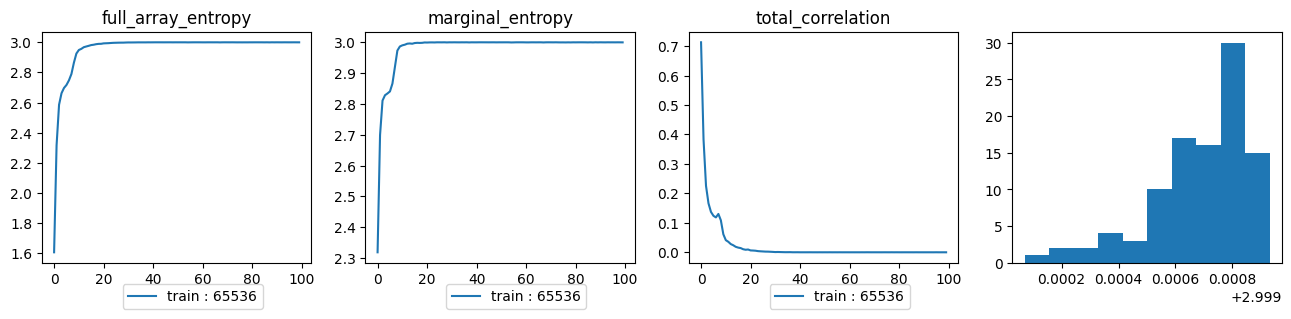

In [12]:
fig,ax = plt.subplots(ncols=4,figsize=(4*4,3))
for i,key in enumerate(stat.keys()):
    ax[i].plot(stat[key],label=f'train : {N_train}')
    ax[i].set_title(key)

ax[3].hist(ent_test)

for i in range(3):
    ax[i].legend(loc=(0.3,-.2))
#ax[2].set_ylim(0.1,0.6)

Fitting UMAP... (This may take a few seconds)


(<Figure size 500x400 with 1 Axes>,
 <Axes: title={'center': 'UMAP Projection of 3D Chemical Latent Space'}, xlabel='UMAP Dimension 1', ylabel='UMAP Dimension 2'>)

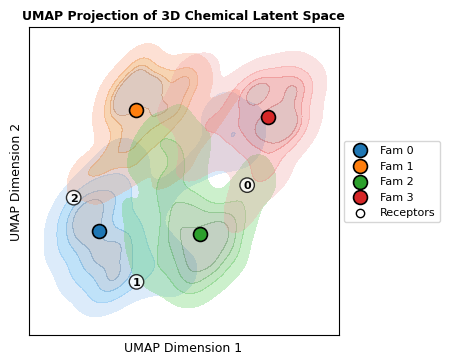

In [13]:
env,rec,loss_fn,optimize = initialize(CONF,SymmetricEnv=True)
plot_latent_umap(env,CONF["receptor_indices"])

In [14]:
#CONF["receptor_indices"] = generate_cascading_receptors(n_units=CONF["n_units"], k_sub=CONF['k_sub'], n_sensors=3)
CONF['receptor_indices'] = torch.tensor([[0,0,0,0,0],[1,1,1,1,1],[0,0,1,1,1]],dtype=torch.long)
print(CONF['receptor_indices'])

tensor([[0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1],
        [0, 0, 1, 1, 1]])


Fitting UMAP... (This may take a few seconds)


(<Figure size 500x400 with 1 Axes>,
 <Axes: title={'center': 'UMAP Projection of 3D Chemical Latent Space'}, xlabel='UMAP Dimension 1', ylabel='UMAP Dimension 2'>)

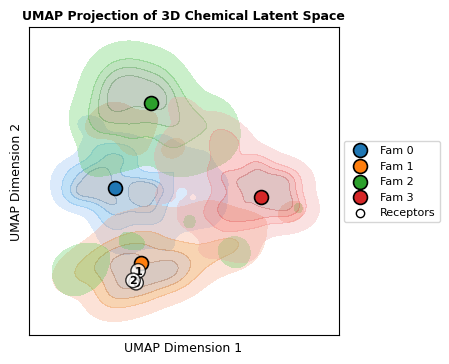

In [15]:
env,rec,loss_fn,optimize = initialize(CONF,SymmetricEnv=True)
plot_latent_umap(env,CONF["receptor_indices"])

In [16]:
stat = train(CONF,env,rec,loss_fn,optimize)
ent_test = test(CONF,env,rec,loss_fn,optimize,N_samples=N_test,indices = CONF['receptor_indices'])

Training for 5000 epochs...


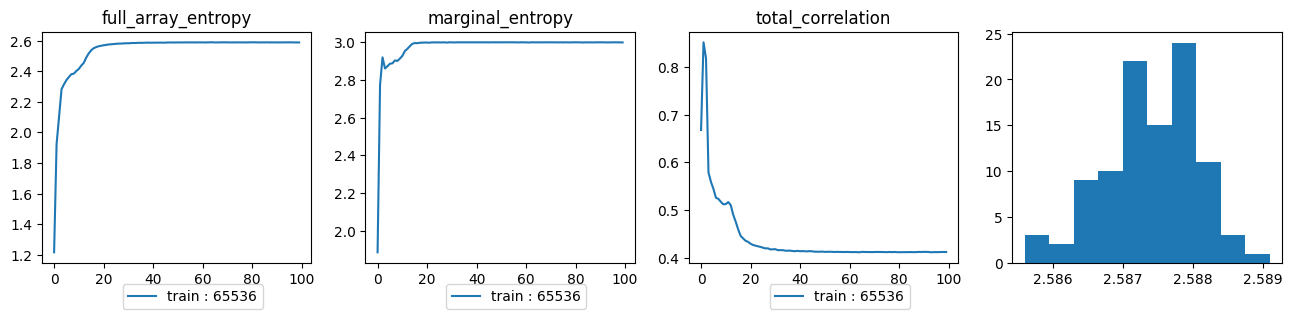

In [17]:
fig,ax = plt.subplots(ncols=4,figsize=(4*4,3))
for i,key in enumerate(stat.keys()):
    ax[i].plot(stat[key],label=f'train : {N_train}')
    ax[i].set_title(key)

ax[3].hist(ent_test)

for i in range(3):
    ax[i].legend(loc=(0.3,-.2))
#ax[2].set_ylim(0.1,0.6)

Fitting UMAP... (This may take a few seconds)


(<Figure size 500x400 with 1 Axes>,
 <Axes: title={'center': 'UMAP Projection of 3D Chemical Latent Space'}, xlabel='UMAP Dimension 1', ylabel='UMAP Dimension 2'>)

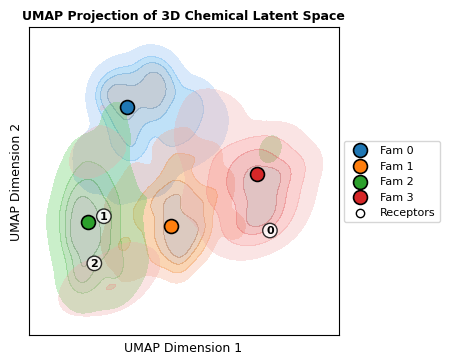

In [18]:
env,rec,loss_fn,optimize = initialize(CONF,SymmetricEnv=True)
plot_latent_umap(env,CONF["receptor_indices"])

# old

In [36]:
ents = []
stats=[]
for N_train in Ns_train:
    CONF['batch_size'] = N_train
    env,rec,loss_fn,optimize = initialize(CONF)
    stats.append(train(CONF,env,rec,loss_fn,optimize))
    ent=[]
    for N_test in Ns_test:
        ent.append(test(CONF,env,rec,loss_fn,optimize,N_samples=N_test,indices = CONF['receptor_indices']))
    ents.append(ent)
ents = np.array(ents)

Training for 5000 epochs...


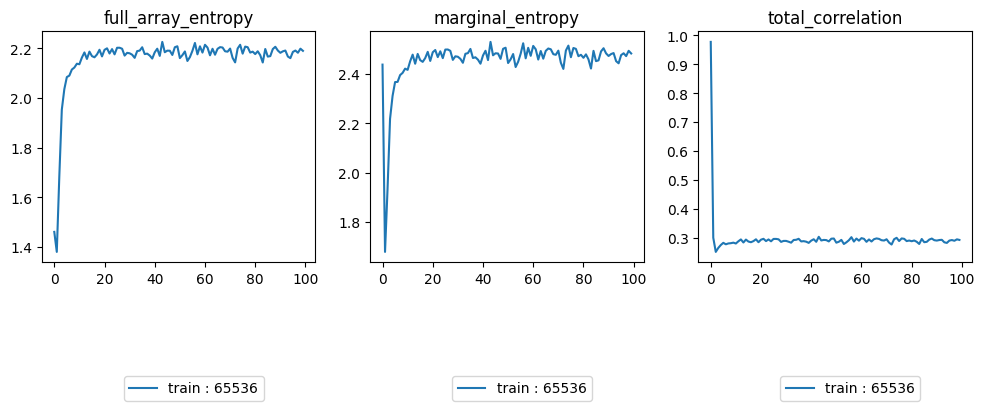

In [37]:
fig,ax = plt.subplots(ncols=3,figsize=(3*4,3))
n=0
for stat in stats:    
    for i,key in enumerate(stat.keys()):
        ax[i].plot(stat[key],label=f'train : {Ns_train[n]}')
        ax[i].set_title(key)
    n+=1
for i in range(3):
    ax[i].legend(loc=(0.3,-.6))
#ax[2].set_ylim(0.1,0.6)

Fitting UMAP... (This may take a few seconds)


(<Figure size 500x400 with 1 Axes>,
 <Axes: title={'center': 'UMAP Projection of 3D Chemical Latent Space'}, xlabel='UMAP Dimension 1', ylabel='UMAP Dimension 2'>)

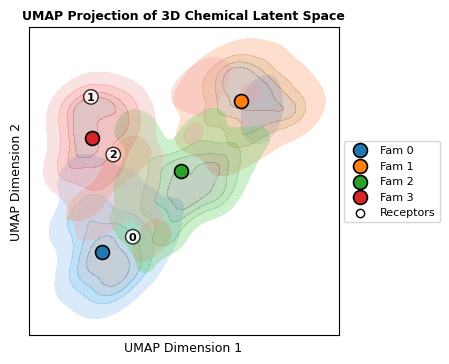

In [38]:
env,rec,loss_fn,optimize = initialize(CONF,SymmetricEnv=True)
plot_latent_umap(env,CONF["receptor_indices"])